# DATA266 Lab 1 - Task 1

Rishitha Gogineni  
Team 28

GPT-style character-level language model trained from scratch on TinyStories.


## 1. Environment

The saved environment manifest below records the environment used for the final training run.


In [1]:
from pathlib import Path
import json, csv
cwd = Path.cwd()
root = cwd if (cwd / 'config').exists() else cwd.parent
print((root / 'manifest' / 'environment.txt').read_text(encoding='utf-8'))


python=3.11.9
pytorch=2.7.1+cu118
numpy=2.4.6
cuda_available=True
pytorch_cuda=11.8
datasets=5.0.1
matplotlib=3.11.2
gpu=NVIDIA GeForce RTX 2070 Super with Max-Q Design
gpu_memory_gb=8.0



## 2. Final configuration

The final model uses 6 Transformer blocks, 6 attention heads, hidden size 384, FFN size 1536, context length 256, Pre-LayerNorm, GELU, and causal masking.


In [2]:
with open(root / 'config' / 'gpt_config.json', 'r', encoding='utf-8') as f:
    config = json.load(f)
config


{'team_number': 28,
 'student_name': 'Rishitha_Gogineni',
 'seed': 42,
 'data': {'dataset_name': 'roneneldan/TinyStories',
  'train_stories': 100000,
  'val_stories': 10000,
  'context_length': 256,
  'sequence_stride': 256,
  'num_workers': 0},
 'model': {'hidden_size': 384,
  'num_layers': 6,
  'num_heads': 6,
  'ffn_size': 1536,
  'dropout': 0.1,
  'normalization': 'pre_ln'},
 'training': {'batch_size': 16,
  'epochs': 10,
  'learning_rate': 0.0003,
  'weight_decay': 0.01,
  'warmup_ratio': 0.05,
  'grad_clip': 1.0,
  'use_amp': True,
  'log_every': 100,
  'sample_every_epoch': True},
 'generation': {'max_new_chars': 500,
  'temperature': 0.8,
  'prompt': 'Once upon a time'}}

## 3. Reproducible commands

The smoke test can be run with `python src/train.py --config config/gpt_config.json --smoke-test`. The completed final training run is preserved in the raw log and checkpoints, so this submission notebook displays that saved evidence instead of retraining the model.


## 4. Final training evidence

Final run ID: `20260925_163912`. The last epoch line from the untouched raw log is shown below.


In [3]:
log_path = root / 'logs' / 'raw' / 'train_20260925_163912.log'
lines = log_path.read_text(encoding='utf-8', errors='replace').splitlines()
epoch_lines = [line for line in lines if line.startswith('epoch=')]
print(epoch_lines[-1])


epoch=10 train_loss=0.6066 val_loss=0.5809 val_top1=0.8144 epoch_time_sec=1245.62 tokens_per_sec=71852.74


## 5. Training and validation loss curves


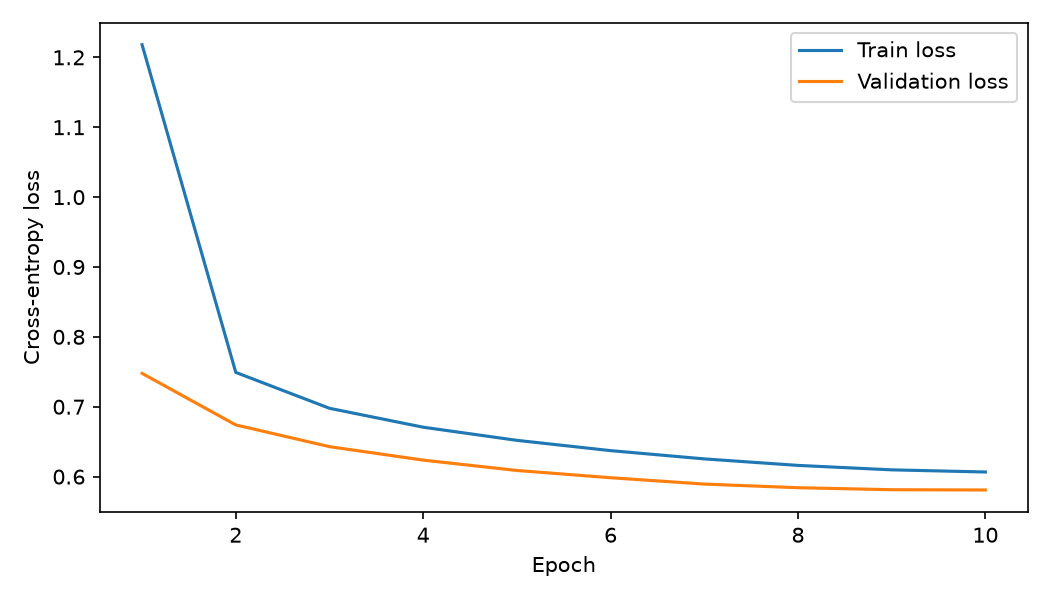

In [4]:
from IPython.display import Image, display
loss_plot = root / 'outputs' / 'plots' / 'loss_curve.png'
display(Image(filename=str(loss_plot)))


## 6. Gradient norm / training stability


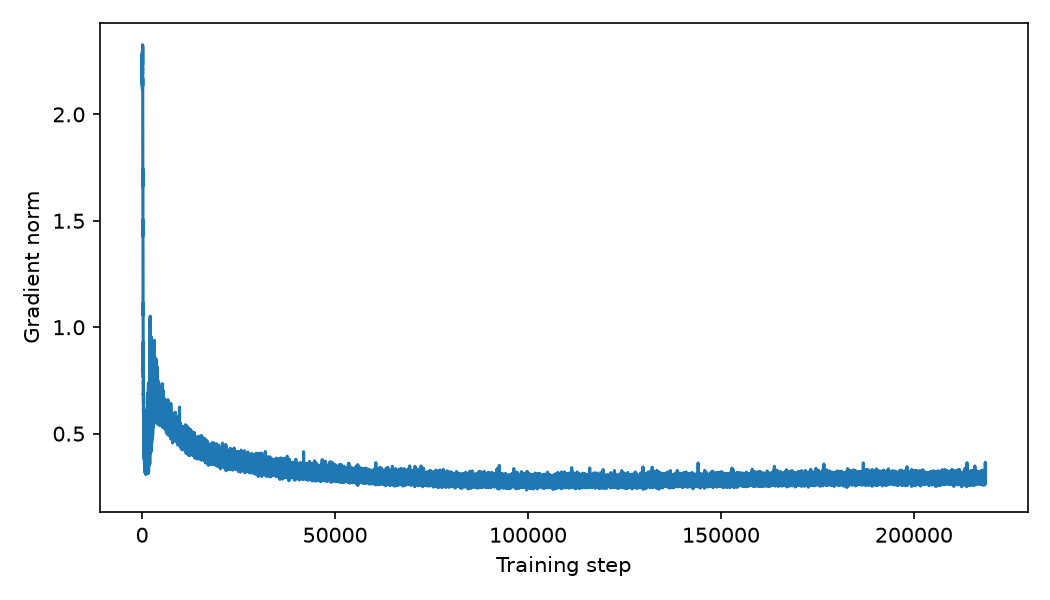

In [5]:
grad_plot = root / 'outputs' / 'plots' / 'gradient_norm.png'
display(Image(filename=str(grad_plot)))


## 7. Final metrics

These values come from the final run and are stored in `metrics_report.csv`.


In [6]:
metrics = {}
with open(root / 'metrics_report.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader)
    for name, value in reader:
        metrics[name] = value
for name, value in metrics.items():
    print(f'{name}: {value}')


run_id: 20260925_163912
train_cross_entropy_loss: 0.606602
validation_cross_entropy_loss: 0.580865
perplexity: 1.787584
bits_per_character: 0.838011
generalization_gap: -0.025737
top1_next_character_accuracy: 0.814389
average_gradient_norm: 0.311110
minimum_gradient_norm: 0.2431
maximum_gradient_norm: 2.2054
loss_spike_count: 0
nan_or_non_finite_loss_count: 0
parameter_count: 10834176
training_tokens_per_sec: 71314.54
generation_tokens_per_sec: 96.37
peak_memory_gb: 0.823
total_training_time_seconds: 12550.20
distinct_1: 0.074000
distinct_2: 0.334669
distinct_3: 0.610442
repeated_4gram_rate: 0.255533


## 8. Final generated sample

The sample below was generated from `20260925_163912_best.pt` with prompt `Once upon a time` and temperature 0.8.


In [7]:
sample = root / 'outputs' / 'generations' / 'sample_20260925_163912_Final.txt'
print(sample.read_text(encoding='utf-8'))


Once upon a time, there was a little girl named Lily. She loved to play outside and explore the world around her. One day, she wanted to go on an adventure to find something to explore. Her mommy said "Wait and bury!" But Lily was still foolish and didn't want to.

After a while, Lily's mommy found her and asked her what was wrong. Lily told her about the sharp stone and her mommy told her that she had to do a something special. Lily was sad and promised to never give up. She wanted to help the sharp stone, but


## 9. Generation metrics


In [8]:
gen_metrics = root / 'outputs' / 'generations' / 'generation_metrics_20260925_163912.csv'
print(gen_metrics.read_text(encoding='utf-8'))


metric,value
run_id,20260925_163912
checkpoint,checkpoints\20260925_163912_best.pt
generated_characters,500
prompt,Once upon a time
prompt_characters,16
evaluated_generated_characters,500
generation_time_seconds,5.1883
generation_tokens_per_sec,96.37
distinct_1,0.074000
distinct_2,0.334669
distinct_3,0.610442
repeated_4gram_rate,0.255533


## 10. Failure analysis


In [9]:
print((root / 'failure_analysis.md').read_text(encoding='utf-8'))


# Task 1 Failure Analysis

The examples below come from the final generated sample for run `20260925_163912` using the best checkpoint, prompt `Once upon a time`, and temperature 0.8.

## Failure 1

**Generated text:** "Her mommy said \"Wait and bury!\""

**Failure type:** Loss of coherence / incorrect word choice

**Observation:** The sentence is grammatically shaped like dialogue, but "bury" does not fit the situation described in the story. The model learned common sentence patterns but sometimes chooses a locally plausible character sequence that gives the sentence the wrong meaning.

## Failure 2

**Generated text:** "she had to do a something special."

**Failure type:** Broken grammar

**Observation:** The phrase uses both "a" and "something" together, which makes the sentence ungrammatical. This shows that the character-level model can produce readable sentences while still making small grammatical errors over longer sequences.

## Failure 3

**Generated text:** "She wanted to 

## 11. Results summary


In [10]:
print((root / 'results.md').read_text(encoding='utf-8'))


# Task 1 Results

## Student

Rishitha Gogineni  
Team 28

## Dataset

I used the TinyStories dataset with character-level tokenization. The final split contains 100,000 training stories and 10,000 validation stories. Characters are converted to integer IDs using my own `char_to_idx` and `idx_to_char` mappings. Input sequences have a context length of 256 and the target is the same sequence shifted by one character for next-character prediction.

## Architecture

- Transformer blocks: 6
- Attention heads: 6
- Hidden size: 384
- Head size: 64
- FFN size: 1536
- Context length: 256
- Normalization: Pre-LayerNorm
- Activation: GELU
- Dropout: 0.1
- Parameters: 10,834,176

## Architecture choice

I used 6 Transformer blocks and 6 attention heads to give the model enough capacity to learn the structure of TinyStories while keeping the model small enough to train on the available GPU. With a hidden size of 384, each attention head has dimension 64. The FFN size is 1536, which is four times t

## 12. Submission check

The final package includes the source code, configuration, trained checkpoints, raw logs, environment manifest, loss and gradient plots, metrics report, generated sample, failure analysis, and results summary.
